In [16]:
import pickle as pkl
import pk_plot_library as pplib
import numpy as np
import matplotlib.pyplot as plt
from figrid.data_container import DataContainer
from figrid.data_sort import DataSort
import copy

redshifts = [0, 0.5, 1]
snapshots = [99, 67, 50]
omegahis = [7.4e-4, 6.663e-4, 6e-4]
color_idxs = ['blue', 'red', 'resolved']
DRAFTPATH = '/Users/cosinga/overleaf/hi_cosmo_apj/figures/omega/'

# model name shorthands
MK = 'mK'
TK = 'tK'
CB = 'cB'
SB = 'sB'
FOG = 'FoG'
XPK_PRE = ''
AUTO_PRE = ''
CONJ = '+'
def get_actual_name(is_cross, letter):
    if is_cross:
        if letter == 'A':
            return f"{MK}{CB}"
        elif letter == 'B':
            return f"{TK}{CB}"
        elif letter == 'C':
            return f"{TK}{CB}{FOG}"
        elif letter == 'D':
            return f"{TK}{SB}{FOG}"
    else:
        out = f"{TK}"
        if letter == 'A':
            return out + f"{CB}"
        elif letter == 'B':
            return out + f"{SB}"
        elif letter == 'C':
            return out + f"{CB}{FOG}"
        elif letter == 'D':
            return out + f"{SB}{FOG}"
        
def omegam(snap):
    a = 1 / (1 + redshifts[snap])
    om0 = 0.3089 # from TNG website
    oml = 0.6911 # from TNG website
    return om0 * a**-3 / (oml + om0 * a**-3)

def thi(omegahi, snap):
    h = 0.6774
    om = omegam(snap); oml = 0.6911
    return 180 * omegahi * h * (1 + redshifts[snap])**2 / (om * (1 + redshifts[snap])**3 + oml)**0.5

def omegahi(thi, snap):
    h = 0.6774
    om = omegam(snap); oml = 0.6911
    return thi / 180 / h / (1 + redshifts[snap])**2 * np.sqrt(om * (1 + redshifts[snap])**3 + oml)

def get_key(model, color, snap):
    return '%s_%s_%d'%(model, color, snap)

def key_to_vals(key):
    splt = key.split('_')
    return splt[0], splt[1], int(splt[2])

def plot_f(ax, data, kwargs):
    ax.errorbar(data[0], data[1], yerr = data[2], marker = 'o', **kwargs)
    return

def make_ds():
    thi = pkl.load(open('thi_fits.pkl', 'rb'))
    wnum = pkl.load(open('k_fits.pkl', 'rb'))
    cov = pkl.load(open('cov_fits.pkl', 'rb'))
    
    thi_auto = pkl.load(open('thi_fits_auto.pkl', 'rb'))
    cov_auto = pkl.load(open('cov_fits_auto.pkl', 'rb'))
    
    thi.update(thi_auto)
    cov.update(cov_auto)
    
    dclist = []
    for ss in snapshots:
        k_attr = {'x':'keff', 'model':'sim', 'color':'none', 'snapshot':ss, 'keff':'none'}
        snap_idx = snapshots.index(ss)
        ksnap = wnum[ss]
        keff = []
        for i in range(len(ksnap)):
            keff.append(np.sum(ksnap[i]) / len(ksnap[i]))
        data = [keff, np.array([omegahis[snap_idx]] * len(keff)) * 1e3, np.zeros_like(keff)]
        dc = DataContainer(data)
        dc.update(k_attr)
        dc.setFunc(plot_f)
        dclist.append(dc)
    
    for k, v in thi.items():
        k_attr = {'x':'keff', 'keff':'none'}
        model, color, snap = key_to_vals(k)
        
        is_cross = not color == 'HI'
        k_attr['model'] = get_actual_name(is_cross, model)
        k_attr['color'] = color
        k_attr['snapshot'] = snap
        ksnap = wnum[snap]
        snap_idx = snapshots.index(snap)
        keff = []
        yerr = []
        for i in range(len(ksnap)):
            keff.append(np.sum(ksnap[i]) / len(ksnap[i]))
            uncert_thi = np.sqrt(np.diag(cov[k][i]))[0][0]
            yerr.append(omegahi(uncert_thi, snap_idx))
        omegas = omegahi(np.array(v), snap_idx)
        data = [keff, omegas * 1e3, np.array(yerr) * 1e3]
        k_dc = DataContainer(data)
        k_dc.setFunc(plot_f)
        k_dc.update(k_attr)
        
        dclist.append(k_dc)
    

    
    return DataSort(dclist)

def plot_lines(fg, snap_ax):
    shape = fg.axes.shape
    for i in range(shape[0]):
        for j in range(shape[1]):
            if snap_ax == 0:
                snap_idx = i
            else:
                snap_idx = j
            xlim = fg.axes[i, j].get_xlim()
            fg.axes[i, j].axhline(omegahis[snap_idx] * 1e3, xlim[0], xlim[1], color = 'k', linestyle = 'dashed')
    return

def make_ratios(fg):
    for ss in snapshots:
        snapidx = snapshots.index(ss)
        omega_hi_val = omegahis[snapidx] * 1e3
        def rat_func(dc):
            data = dc.getData()
            data[1] /= omega_hi_val
            data[2] /= omega_hi_val
            dc.setData(data)
            return dc
        
        fg.adjustData({'snapshot':ss}, rat_func)
    return

In [17]:
import itertools
def add_zdcs(ds):
    models = ds.getAttrVals('model')
    snapshots = ds.getAttrVals('snapshot')
    colors = ds.getAttrVals('color')
    attrs = ds.getAttrs()
    print(attrs)
    keff_vals = ds.dclist[0].getData()[0]
    print(keff_vals)
    for (m, c, k) in itertools.product(models, colors, range(len(keff_vals))):
        ss_vals = np.zeros(len(redshifts))
        uncert = np.zeros_like(ss_vals)
        skip = False
        for j, ss in enumerate(snapshots):
            ip_vals = ['keff', m, c, ss, 'none']
            ip = {attrs[i]:ip_vals[i] for i in range(len(ip_vals))}
            matches = ds.getMatching(ip)
            if len(matches) == 0:
                skip = True
                continue
            match = matches[0]
            ss_vals[j] = match.getData()[1][k]
            uncert[j] = match.getData()[2][k]
        if skip:
            continue
        z_dc = DataContainer([redshifts, ss_vals, uncert])
        ip['snapshot'] = 'none'
        ip['x'] = 'z'
        ip['keff'] = keff_vals[k]
        z_dc.update(ip)
        z_dc.setFunc(plot_f)
        ds.append(z_dc)

    return

In [18]:
ds = make_ds()
print(len(ds.dclist))
add_zdcs(ds)
print(len(ds.dclist))

51
['x', 'model', 'color', 'snapshot', 'keff']
[0.058484788755518366, 0.1666103960728116, 0.2589540814816316, 0.5199428988973769, 1.010693730229297, 2.512854853219676, 5.010960614657268]
170


In [19]:
# set defaults
ds.tickArgs(direction = 'in', right = True, top = True, labelsize = 14)
ds.legendArgs(frameon = False, loc = 'upper right', fontsize = 12, slc = (-1, -1))

ds.rowLabelArgs(pos = [0.05, 0.05], fontsize = 13, ha = 'left', va = 'bottom')
ds.colLabelArgs(pos = [0.5, 0.95], fontsize = 13, ha = 'center', va = 'top')

ds.axisArgs(xscale = 'log', ylim = (0.1, 1.05))
ds.axisLabelArgs('both', fontsize = 16)

ds.setColors('color', ['red', 'blue', 'gray'], ['red', 'blue', 'resolved'])
ds.setColors('snapshot', 'viridis', snapshots)

ds.displayAs('snapshot', [99, 67, 50], ['z = 0.0', 'z = 0.5', 'z = 1.0'])
xmodels = [get_actual_name(True, letter) for letter in 'ABCD']
amodels = [get_actual_name(False, letter) for letter in 'ABCD']
ds.displayAs('model', xmodels, [f'{XPK_PRE}{MK}{CONJ}{CB}', f'{XPK_PRE}{TK}{CONJ}{CB}', f'{XPK_PRE}{TK}{CONJ}{CB}{CONJ}{FOG}', f'{XPK_PRE}{TK}{CONJ}{SB}{CONJ}{FOG}'])
ds.setYLabel(r'$\Omega_{\mathrm{HI}} \times 10^3$')
ds.displayAs('color', ['red', 'blue', 'resolved', 'HI'],
            ['HI $\\times$ Red', 'HI $\\times$ Blue',
            'HI $\\times$ All Gal.', 'HI Auto'])
ds.setColors('model', 'cividis', xmodels)
ds.setColors('model', 'cividis', amodels)

ds.gspecArgs(wspace = 0.01, hspace = 0.01)
RATIO_LABEL = r'$\frac{\Omega_{\mathrm{HI, fit}}}{{\Omega_{\mathrm{HI, TNG}}}}$'

The row values for color: ['blue', 'red', 'resolved', 'HI']
The column values for snapshot: [99, 67, 50]


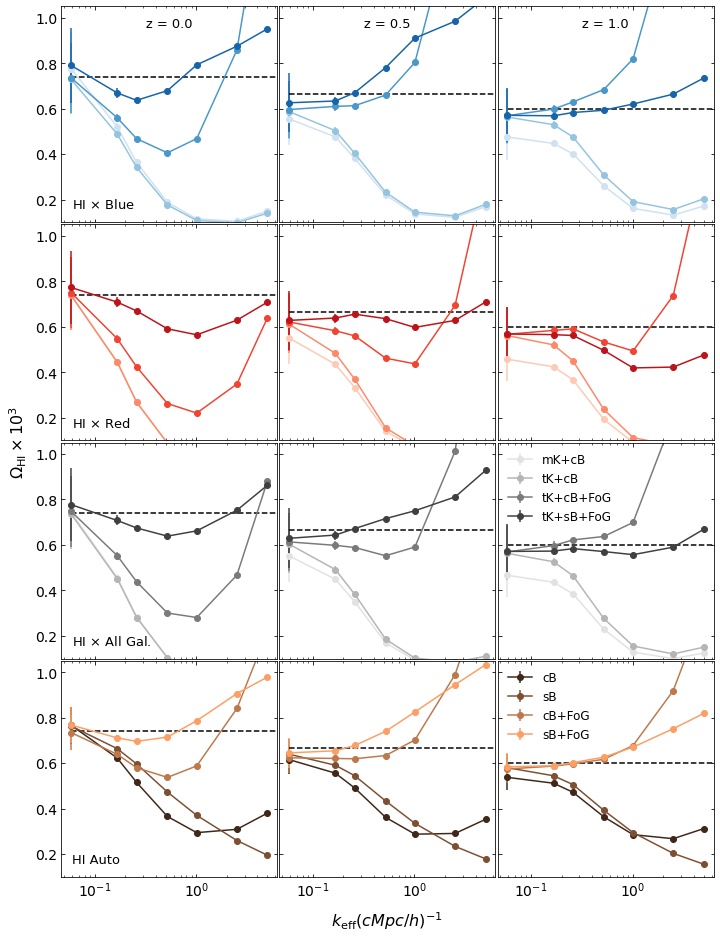

In [23]:
# panel: model, row: color, col : snapshot
import seaborn as sbn
ip = {'x':'keff', 'snapshot':snapshots, 'color':color_idxs + ['HI']}
fg = ds.figrid('model', 'color', 'snapshot', ip)
auto_model_names = [f'{AUTO_PRE}{CB}', f'{AUTO_PRE}{SB}', f'{AUTO_PRE}{CB}{CONJ}{FOG}', f'{AUTO_PRE}{SB}{CONJ}{FOG}']

hi_colors = sbn.color_palette('copper', len(models))
blue_colors = sbn.color_palette('Blues', len(models))
red_colors = sbn.color_palette('Reds', len(models))
gal_colors = sbn.color_palette('Greys', len(models))
for i,mod in enumerate(models):
    amod = get_actual_name(False, mod)
    xmod = get_actual_name(True, mod)
    fg.plotArgs({'color':'HI', 'model':amod}, label = auto_model_names[i], color = hi_colors[i])
    fg.plotArgs({'color':'red', 'model':xmod}, color = red_colors[i])
    fg.plotArgs({'color':'blue', 'model':xmod}, color = blue_colors[i])
    fg.plotArgs({'color':'resolved', 'model':xmod}, color = gal_colors[i])
fg.legendArgs(loc = 'upper left', slc = [(2, 2), (3, 2)])
fg.setXLabel(r'$k_{\mathrm{eff}} (cMpc / h)^{-1}$')
fg.setYLabel(r'$\Omega_{\mathrm{HI}} \times 10^3$', fontsize = 16)

fg.setDefaultTicksParams()
fg.plot()
plot_lines(fg, 1)
fg.save(DRAFTPATH + "omega_vals_all_snaps.pdf", dpi = 200)

The row values for color: ['blue', 'red', 'resolved', 'HI']
The column values for snapshot: [99, 67, 50]


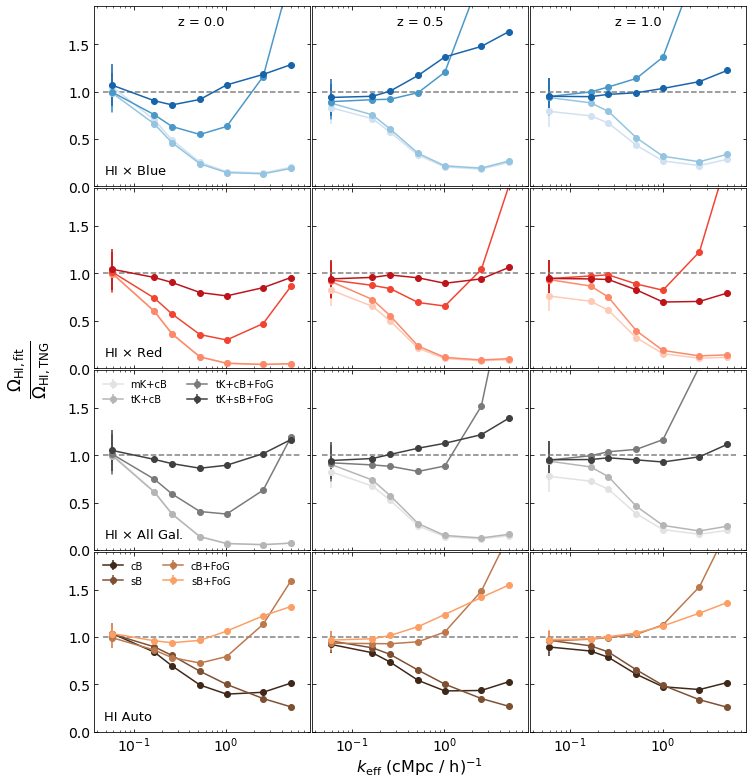

In [24]:
# ratio
import seaborn as sbn
ip = {'x':'keff', 'snapshot':snapshots, 'color':color_idxs + ['HI']}
fg = ds.figrid('model', 'color', 'snapshot', ip)
fg.setPanelsize(3, 2.5)
make_ratios(fg)
hi_colors = sbn.color_palette('copper', len(models))
blue_colors = sbn.color_palette('Blues', len(models))
red_colors = sbn.color_palette('Reds', len(models))
gal_colors = sbn.color_palette('Greys', len(models))
for i,mod in enumerate(models):
    amod = get_actual_name(False, mod)
    xmod = get_actual_name(True, mod)
    fg.plotArgs({'color':'HI', 'model':amod}, label = auto_model_names[i], color = hi_colors[i])
    fg.plotArgs({'color':'red', 'model':xmod}, color = red_colors[i])
    fg.plotArgs({'color':'blue', 'model':xmod}, color = blue_colors[i])
    fg.plotArgs({'color':'resolved', 'model':xmod}, color = gal_colors[i])
fg.gspecArgs(xborder = [0.4, 0])
fg.legendArgs(loc = 'upper left', slc = (1, 0), ncol = 2, fontsize = 10)
fg.axisArgs(ylim = (0, 1.9))
fg.setXLabel(r'$k_{\mathrm{eff}}$ (cMpc / h)$^{-1}$')
fg.setYLabel(RATIO_LABEL, fontsize = 24)
fg.setDefaultTicksParams()
fg.legendArgs(loc = 'upper left', slc = [(2, 0), (3, 0)])

fg.plotOnes()
fg.plot()
fg.save(DRAFTPATH + 'omegahi_kdep_model_compare_all_snaps.pdf', dpi = 200)

The row values for color: ['blue', 'red', 'HI']
The column values for snapshot: [99, 67, 50]


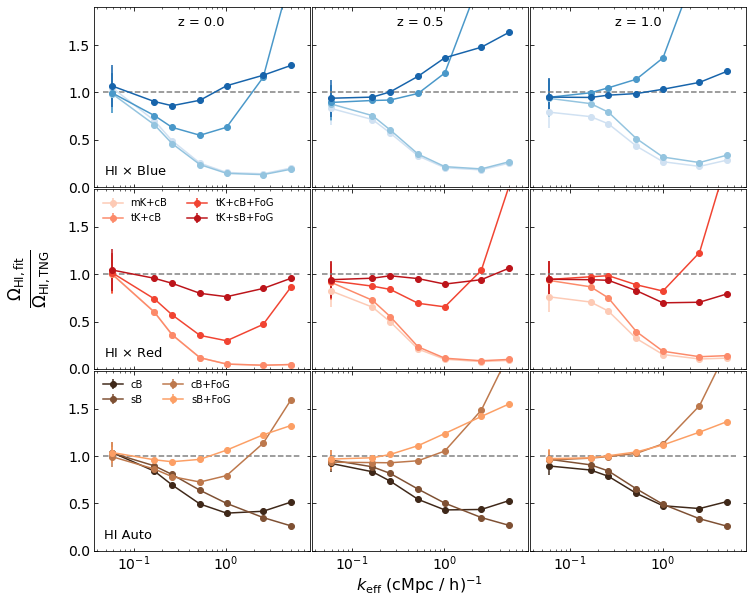

In [25]:
# ratio
ip = {'x':'keff', 'snapshot':snapshots, 'color':['blue', 'red', 'HI']}
fg = ds.figrid('model', 'color', 'snapshot', ip)
fg.setPanelsize(3, 2.5)
make_ratios(fg)
fg.gspecArgs(xborder = [0.4, 0])
fg.legendArgs(loc = 'upper left', slc = [(1, 0), (2, 0)], ncol = 2, fontsize = 10)
for i,mod in enumerate(models):
    amod = get_actual_name(False, mod)
    xmod = get_actual_name(True, mod)
    fg.plotArgs({'color':'HI', 'model':amod}, label = auto_model_names[i], color = hi_colors[i])
    fg.plotArgs({'color':'red', 'model':xmod}, color = red_colors[i])
    fg.plotArgs({'color':'blue', 'model':xmod}, color = blue_colors[i])
    fg.plotArgs({'color':'resolved', 'model':xmod}, color = gal_colors[i])
fg.axisArgs(ylim = (0, 1.9))
fg.setXLabel(r'$k_{\mathrm{eff}}$ (cMpc / h)$^{-1}$')
fg.setYLabel(RATIO_LABEL, fontsize = 24)
fg.setDefaultTicksParams()
fg.plotOnes()
fg.plot()
fg.save(DRAFTPATH + 'omegahi_kdep_model_compare_color_only.pdf', dpi = 200)

The row values for snapshot: [67, 50]
The column values for color: ['blue', 'red', 'resolved', 'HI']


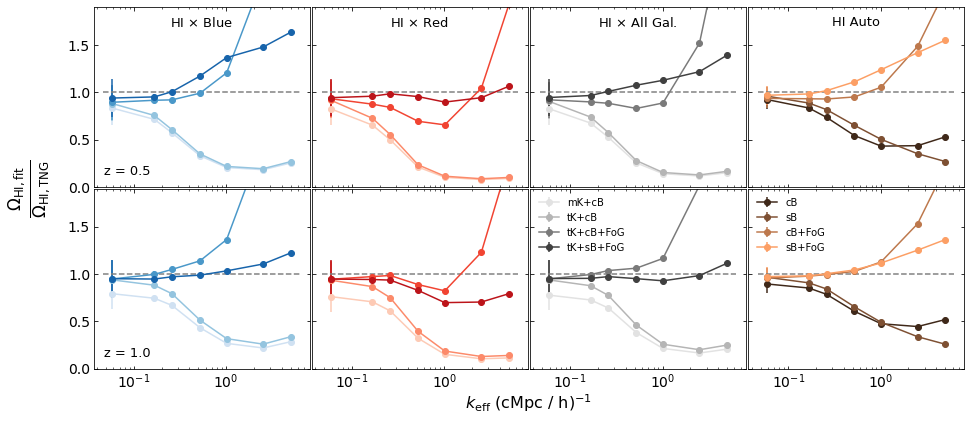

In [28]:
# just at z = 0.5, z = 1
ip = {'x':'keff', 'snapshot':[67, 50], 'color':color_idxs + ['HI']}
fg = ds.figrid('model', 'snapshot', 'color', ip)
fg.setPanelsize(3, 2.5)
make_ratios(fg)
fg.gspecArgs(xborder = [0.4, 0])
fg.legendArgs(loc = 'upper left', slc = [(1, 2), (1, 3)], fontsize = 10)
for i,mod in enumerate(models):
    amod = get_actual_name(False, mod)
    xmod = get_actual_name(True, mod)
    fg.plotArgs({'color':'HI', 'model':amod}, label = auto_model_names[i], color = hi_colors[i])
    fg.plotArgs({'color':'red', 'model':xmod}, color = red_colors[i])
    fg.plotArgs({'color':'blue', 'model':xmod}, color = blue_colors[i])
    fg.plotArgs({'color':'resolved', 'model':xmod}, color = gal_colors[i])
fg.axisArgs(ylim = (0, 1.9))
fg.setXLabel(r'$k_{\mathrm{eff}}$ (cMpc / h)$^{-1}$')
fg.setYLabel(RATIO_LABEL, fontsize = 24)
fg.setDefaultTicksParams()
fg.plotOnes()
fg.plot()
fg.save(DRAFTPATH + 'omegahi_kdep_model_compare_color_only.pdf', dpi = 200)

The row values for model: ['tKcB', 'tKcBFoG', 'tKsBFoG']
The column values for snapshot: [99, 67, 50]


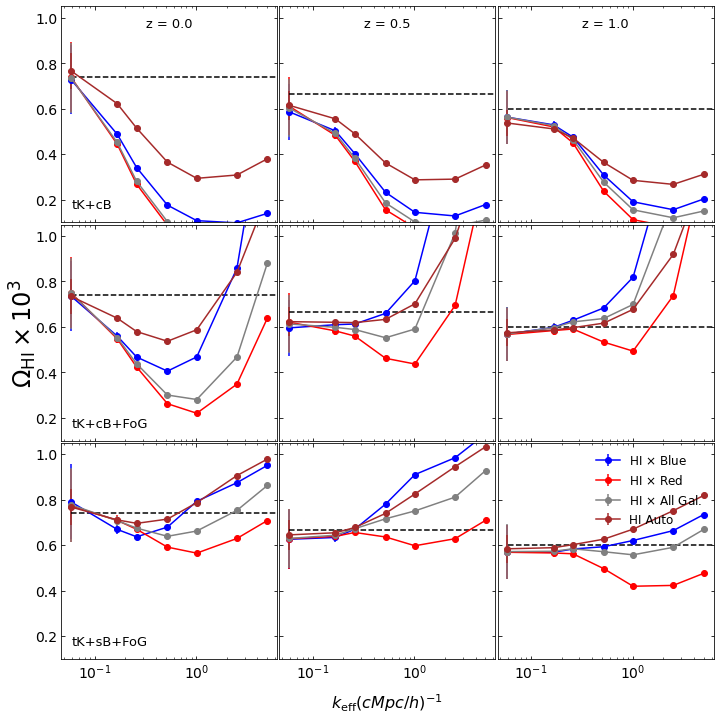

In [31]:
# panel: color, row: snapshot, col: model
ip = {'x':'keff', 'snapshot':snapshots, 'model':[get_actual_name(True, letter) for letter in 'BCD']}
fg = ds.figrid('color', 'model', 'snapshot', ip)
fg.legendArgs()
fg.plotArgs({'color':'HI'}, color = 'brown')
fg.setXLabel(r'$k_{\mathrm{eff}} (cMpc / h)^{-1}$')
fg.setDefaultTicksParams()
fg.plot()
plot_lines(fg, 1)

The row values for snapshot: [99, 67, 50]
The column values for model: ['tKcB', 'tKcBFoG', 'tKsBFoG']


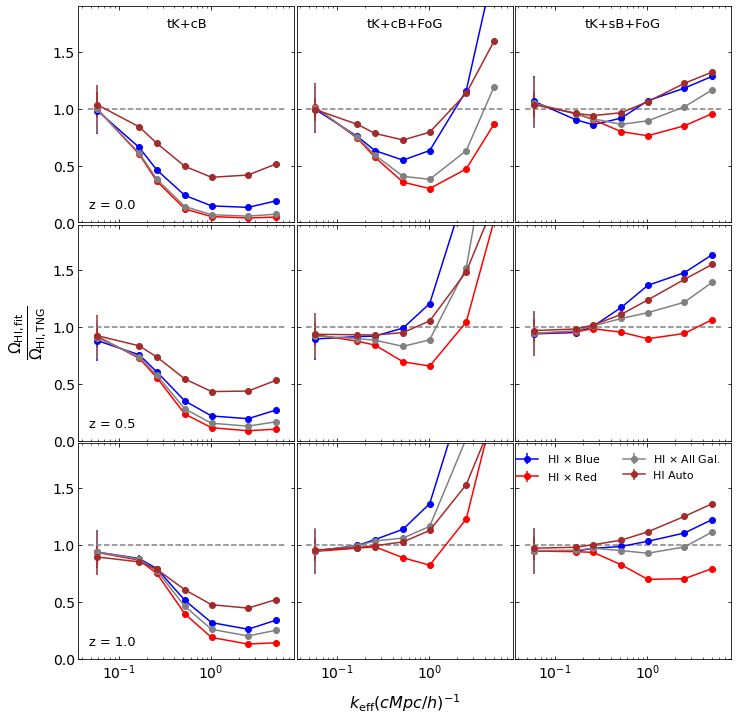

In [37]:
# ratio
ip = {'x':'keff', 'snapshot':snapshots, 'model':[get_actual_name(True, letter) for letter in 'BCD']}
fg = ds.figrid('color', 'snapshot', 'model', ip)
make_ratios(fg)
fg.gspecArgs(xborder = [0.33, 0])
fg.legendArgs(ncol = 2, fontsize = 11)
fg.axisArgs(ylim = (0, 1.9))
fg.setXLabel(r'$k_{\mathrm{eff}} (cMpc / h)^{-1}$')
fg.plotArgs({'color':'HI'}, color = 'brown')

fg.setYLabel(RATIO_LABEL, fontsize = 22)
fg.setDefaultTicksParams()
fg.plotOnes()
fg.plot()

The row values for color: ['none', 'blue', 'red', 'resolved', 'HI']
The column values for model: ['tKcB', 'tKcBFoG', 'tKsBFoG']


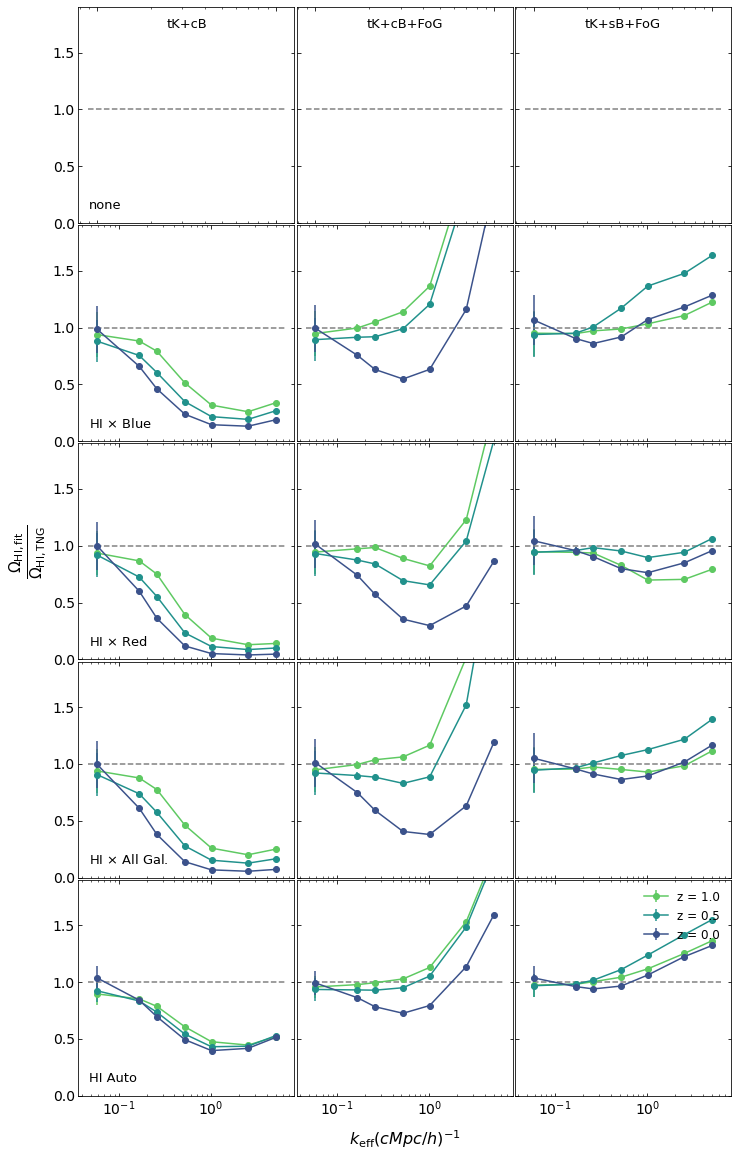

In [38]:
# panel: snapshot, row: color, col : model (just ratio)
ip = {'x':'keff', 'snapshot':snapshots, 'model':[get_actual_name(True, letter) for letter in 'BCD']}
fg = ds.figrid('snapshot', 'color', 'model', ip)
make_ratios(fg)
fg.gspecArgs(xborder = [0.33, 0])
fg.legendArgs()
fg.axisArgs(ylim = (0, 1.9))
fg.setXLabel(r'$k_{\mathrm{eff}} (cMpc / h)^{-1}$')
fg.setYLabel(RATIO_LABEL, fontsize = 22)
fg.setDefaultTicksParams()
fg.plotOnes()
fg.plot()

In [13]:
def make_zdata_ratios(fg):
    def _ratio(dc):
        data = dc.getData()
        data[1] /= np.array(omegahis)*1e3
        data[2] /= np.array(omegahis)*1e3
        dc.setData(data)
        return dc
    fg.adjustData({}, _ratio)
    return

def offset_x(fg):
    def _offset_blue(dc):
        data = dc.getData()
        data[0] -= 0.1
        dc.setData(data)
        return dc
    def _offset_red(dc):
        data = dc.getData()
        data[0] += 0.1
        dc.setData(data)
        return dc
    fg.adjustData({'color':'blue'}, _offset_blue)
    fg.adjustData({'color':'red'}, _offset_red)
    return

In [14]:
keff_vals = ds.getAttrVals('keff')

['none',
 0.058484788755518366,
 0.1666103960728116,
 0.2589540814816316,
 0.5199428988973769,
 2.512854853219676,
 5.010960614657268]